# EDA 02 — Chuva (Alerta Rio)
**Projeto de extensão: Ciência de Dados para Cidades Inteligentes**

Segundo notebook da análise exploratória. Aqui olho só a tabela de chuva; os chamados estão no `01_eda_chamados_1746.ipynb`.

No final, salvo a chuva por estação e por dia e a chuva mensal da cidade em `data/processed/`, para usar no `04_cruzamentos.ipynb`.

## 0. Preparando o ambiente
Rodo o notebook de autenticação, que instala as bibliotecas, faz os imports, define o `BILLING_PROJECT_ID` e testa a conexão com o BigQuery. Assim o ID do projeto fica escrito num lugar só.

In [3]:
%run ./00_autenticacao_bigquery.ipynb


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Ambiente pronto! Execute a próxima célula para autenticar.
Downloading: 100%|██████████|


,conexao_ok
0,1


Autenticação concluída! Projeto: etlchamadosrj


# 2. Série temporal: Chuva (Alerta Rio)
Tabela: `datario.clima_pluviometro.taxa_precipitacao_alertario`

Cada linha é uma **medição de chuva de uma estação**, feita a cada 15 minutos. Isso dá 96 medições por dia em cada estação (24 horas × 4 medições por hora).

As colunas de chuva mostram quanto choveu em períodos diferentes: nos últimos 15 minutos, na última 1 hora, 4 horas, 24 horas e 96 horas.

**Algo importante que aprendi:** esses períodos se sobrepõem. O acumulado de 24 horas das 10:00 e o das 10:15 contam quase a mesma chuva, então não dá para somar nem tirar média deles como se fossem medições separadas. Para saber quanto choveu num dia, o certo é **somar as medições de 15 minutos** daquele dia.

## 2.1 Olhando uma amostra

In [4]:
amostra_chuva = bd.read_sql(
    """
    SELECT *
    FROM `datario.clima_pluviometro.taxa_precipitacao_alertario`
    ORDER BY data_particao DESC
    LIMIT 10
    """,
    billing_project_id=BILLING_PROJECT_ID,
)

display(amostra_chuva)
print(list(amostra_chuva.columns))
display(amostra_chuva)
print(list(amostra_chuva.columns))

Downloading: 100%|██████████|


,primary_key,id_estacao,acumulado_chuva_15_min,acumulado_chuva_1_h,acumulado_chuva_4_h,acumulado_chuva_24_h,acumulado_chuva_96_h,horario,data_particao
0,28_2099-03-03 03:30:00,28,NaN,NaN,NaN,NaN,NaN,03:30:00,2099-03-03
1,9_2024-06-03 00:00:00,9,0.0,0.0,0.0,0.0,0.0,00:00:00,2024-06-03
2,9_2024-06-03 00:00:00,9,0.0,0.0,0.0,0.0,0.0,00:00:00,2024-06-03
3,9_2024-06-03 00:00:00,9,0.0,0.0,0.0,0.0,0.0,00:00:00,2024-06-03
4,8_2024-06-03 00:00:00,8,0.0,0.0,0.0,0.0,0.0,00:00:00,2024-06-03
5,10_2024-06-03 00:00:00,10,0.0,0.0,0.0,0.0,0.0,00:00:00,2024-06-03
6,9_2024-06-03 00:00:00,9,0.0,0.0,0.0,0.0,0.0,00:00:00,2024-06-03
7,8_2024-06-03 00:00:00,8,0.0,0.0,0.0,0.0,0.0,00:00:00,2024-06-03
8,8_2024-06-03 00:00:00,8,0.0,0.0,0.0,0.0,0.0,00:00:00,2024-06-03
9,8_2024-06-03 00:00:00,8,0.0,0.0,0.0,0.0,0.0,00:00:00,2024-06-03


['primary_key', 'id_estacao', 'acumulado_chuva_15_min', 'acumulado_chuva_1_h', 'acumulado_chuva_4_h', 'acumulado_chuva_24_h', 'acumulado_chuva_96_h', 'horario', 'data_particao']


,primary_key,id_estacao,acumulado_chuva_15_min,acumulado_chuva_1_h,acumulado_chuva_4_h,acumulado_chuva_24_h,acumulado_chuva_96_h,horario,data_particao
0,28_2099-03-03 03:30:00,28,NaN,NaN,NaN,NaN,NaN,03:30:00,2099-03-03
1,9_2024-06-03 00:00:00,9,0.0,0.0,0.0,0.0,0.0,00:00:00,2024-06-03
2,9_2024-06-03 00:00:00,9,0.0,0.0,0.0,0.0,0.0,00:00:00,2024-06-03
3,9_2024-06-03 00:00:00,9,0.0,0.0,0.0,0.0,0.0,00:00:00,2024-06-03
4,8_2024-06-03 00:00:00,8,0.0,0.0,0.0,0.0,0.0,00:00:00,2024-06-03
5,10_2024-06-03 00:00:00,10,0.0,0.0,0.0,0.0,0.0,00:00:00,2024-06-03
6,9_2024-06-03 00:00:00,9,0.0,0.0,0.0,0.0,0.0,00:00:00,2024-06-03
7,8_2024-06-03 00:00:00,8,0.0,0.0,0.0,0.0,0.0,00:00:00,2024-06-03
8,8_2024-06-03 00:00:00,8,0.0,0.0,0.0,0.0,0.0,00:00:00,2024-06-03
9,8_2024-06-03 00:00:00,8,0.0,0.0,0.0,0.0,0.0,00:00:00,2024-06-03


['primary_key', 'id_estacao', 'acumulado_chuva_15_min', 'acumulado_chuva_1_h', 'acumulado_chuva_4_h', 'acumulado_chuva_24_h', 'acumulado_chuva_96_h', 'horario', 'data_particao']


## 2.2 Tamanho e período
Essa tabela tem medições desde 1997, então é grande demais para trazer inteira. Faço as contas no BigQuery.

In [5]:
consulta_tamanho = """
SELECT
  COUNT(*) AS linhas,
  COUNT(DISTINCT id_estacao) AS estacoes,
  MIN(data_particao) AS primeira_data,
  MAX(data_particao) AS ultima_data
FROM `datario.clima_pluviometro.taxa_precipitacao_alertario`
"""
display(bd.read_sql(consulta_tamanho, billing_project_id=BILLING_PROJECT_ID))

Downloading: 100%|██████████|


,linhas,estacoes,primeira_data,ultima_data
0,29345149,33,1997-01-01,2099-03-03


Consultando dadas futuras, que não existem no banco de dados, para ver quantas linhas possuem tal erro.

In [6]:
linhas_data_irreal = """
SELECT
  COUNT(*) AS qt_linhas,
  MIN(data_particao) AS primeira_data,
  MAX(data_particao) AS ultima_data
FROM `datario.clima_pluviometro.taxa_precipitacao_alertario`
WHERE data_particao > DATE('2026-07-01 18:10:00')
"""
display(bd.read_sql(linhas_data_irreal, billing_project_id=BILLING_PROJECT_ID))

Downloading: 100%|██████████|


,qt_linhas,primeira_data,ultima_data
0,1,2099-03-03,2099-03-03


## 2.3 Valores faltando e valores estranhos
Chuva não pode ser negativa. O primeiro notebook filtrava `acumulado_chuva_24_h >= 0`, o que sugere que existem valores negativos. Eles costumam ser **códigos de erro** do equipamento.

In [7]:
consulta_estranhos = """
SELECT
  COUNTIF(acumulado_chuva_15_min IS NULL) AS nulos,
  COUNTIF(acumulado_chuva_15_min < 0) AS negativos,
  COUNTIF(acumulado_chuva_15_min = 0) AS sem_chuva,
  COUNTIF(acumulado_chuva_15_min > 0) AS com_chuva,
  MAX(acumulado_chuva_15_min) AS maior_valor_15_min
FROM `datario.clima_pluviometro.taxa_precipitacao_alertario`
"""
estranhos = bd.read_sql(consulta_estranhos, billing_project_id=BILLING_PROJECT_ID)
display(estranhos)


Downloading: 100%|██████████|


,nulos,negativos,sem_chuva,com_chuva,maior_valor_15_min
0,114409,0,28001431,1229309,588.4


Na maior parte das medições não chove (valor zero). Por isso a **média** de chuva fica pequena e esconde os temporais, que são o que mais interessa para o projeto. Nas próximas etapas, vou trabalhar com o total de chuva por dia.

Vou **descartar os valores negativos** daqui para frente.

## 2.4 Chuva por dia em cada estação (de 2021 em diante)
Somo as medições de 15 minutos de cada estação em cada dia. Também conto quantas medições existiram no dia:
- **96 medições:** dia completo;
- **menos de 96:** a estação ficou um tempo sem medir;
- **mais de 96:** provavelmente há medições duplicadas.

In [8]:
consulta_chuva_dia = """
SELECT
  id_estacao,
  data_particao AS dia,
  SUM(acumulado_chuva_15_min) AS chuva_mm,
  COUNT(*) AS medicoes
FROM `datario.clima_pluviometro.taxa_precipitacao_alertario`
WHERE data_particao >= '2021-01-01'
  AND acumulado_chuva_15_min >= 0
GROUP BY id_estacao, dia
"""
chuva_dia = bd.read_sql(consulta_chuva_dia, billing_project_id=BILLING_PROJECT_ID)
chuva_dia["dia"] = pd.to_datetime(chuva_dia["dia"].astype(str))
chuva_dia["id_estacao"] = chuva_dia["id_estacao"].astype(str)
chuva_dia["chuva_mm"] = chuva_dia["chuva_mm"].astype(float)
chuva_dia["medicoes"] = chuva_dia["medicoes"].astype(int)

print("Linhas (estação x dia):", len(chuva_dia))
display(chuva_dia.head())

print("Quantas medições cada estação teve por dia:")
display(chuva_dia["medicoes"].describe())

Downloading: 100%|██████████|
Linhas (estação x dia): 39228


,id_estacao,dia,chuva_mm,medicoes
0,9,2023-01-02,0.0,96
1,9,2023-01-04,0.0,94
2,9,2023-01-06,20.2,94
3,9,2023-01-30,1.0,95
4,11,2023-01-29,39.8,95


Quantas medições cada estação teve por dia:


count    39228.000000
mean       109.980957
std         51.106544
min          1.000000
25%         96.000000
50%         96.000000
75%         96.000000
max        288.000000
Name: medicoes, dtype: float64

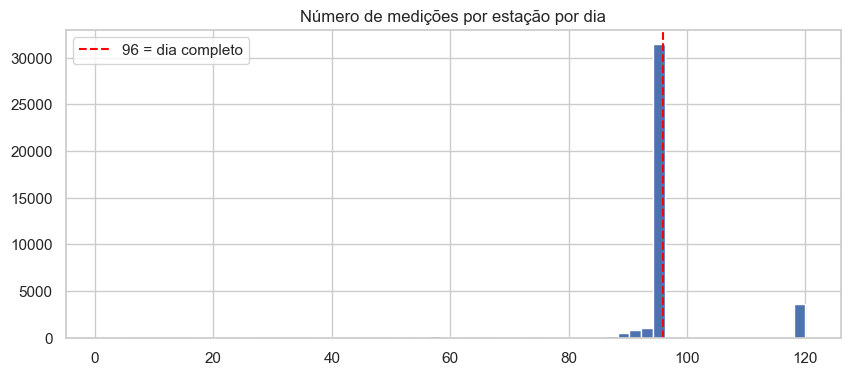

Dias com mais de 96 medições (possível duplicação): 3691
Porcentagem de dias bons: 85.6%


In [9]:
chuva_dia["medicoes"].clip(upper=120).hist(bins=60, figsize=(10, 4))
plt.axvline(96, color="red", linestyle="--", label="96 = dia completo")
plt.title("Número de medições por estação por dia")
plt.legend()
plt.show()

# Considero "dia bom" quando a estação tem entre 90 e 96 medições
chuva_dia["dia_bom"] = chuva_dia["medicoes"].between(90, 96)
print(f"Dias com mais de 96 medições (possível duplicação): {(chuva_dia['medicoes'] > 96).sum()}")
print(f"Porcentagem de dias bons: {100 * chuva_dia['dia_bom'].mean():.1f}%")

## 2.5 Quais estações têm mais falhas?
Para cada estação, calculo a porcentagem de dias bons. Uma estação com muitas falhas pode mostrar menos chuva do que realmente caiu.

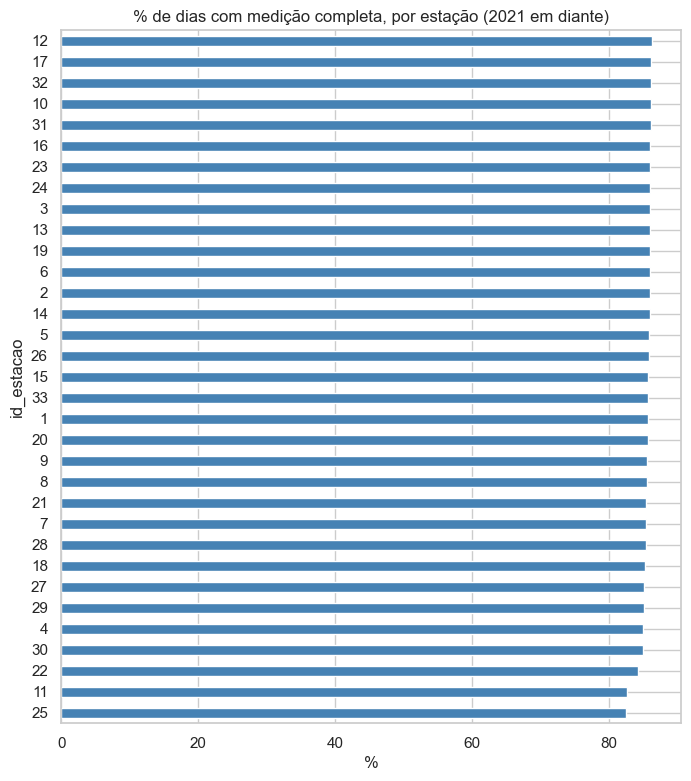

In [10]:
qualidade_estacao = chuva_dia.groupby("id_estacao")["dia_bom"].mean() * 100
qualidade_estacao.sort_values().plot(kind="barh", figsize=(8, 9), color="steelblue")
plt.title("% de dias com medição completa, por estação (2021 em diante)")
plt.xlabel("%")
plt.show()

## 2.6 Quanto choveu na cidade em cada dia?
Para ter um número único por dia, faço a **média entre as estações**, usando só os dias bons.

In [11]:
dias_bons = chuva_dia[chuva_dia["dia_bom"]]
chuva_cidade = dias_bons.groupby("dia")["chuva_mm"].mean()

display(chuva_cidade.describe())
print(f"Dias secos (menos de 1 mm na média da cidade): {100 * (chuva_cidade < 1).mean():.1f}%")

print("\nOs 10 dias mais chuvosos (média das estações):")
display(chuva_cidade.sort_values(ascending=False).head(10).round(1))

count    1029.000000
mean        3.806341
std         9.401055
min         0.000000
25%         0.000000
50%         0.103030
75%         2.687500
max        84.660606
Name: chuva_mm, dtype: float64

Dias secos (menos de 1 mm na média da cidade): 66.0%

Os 10 dias mais chuvosos (média das estações):


dia
2022-04-01    84.7
2023-02-07    79.2
2024-01-21    64.8
2022-03-31    64.1
2022-04-30    63.5
2023-04-08    61.8
2024-01-13    59.1
2024-01-23    56.2
2022-12-21    53.7
2021-02-05    53.4
Name: chuva_mm, dtype: float64

In [12]:
datas = pd.to_datetime(chuva_dia["dia"])
a_partir_2025 = datas >= "2025-01-01"

print("Período em chuva_dia:", datas.min().date(), "até", datas.max().date())
print("Linhas a partir de 2025:", a_partir_2025.sum())
print("Dias bons a partir de 2025:", chuva_dia.loc[a_partir_2025, "dia_bom"].sum())
print("Dias bons no total:", chuva_dia["dia_bom"].sum())

Período em chuva_dia: 2021-01-01 até 2024-06-03
Linhas a partir de 2025: 0
Dias bons a partir de 2025: 0
Dias bons no total: 33569


Esses dias mais chuvosos são bons candidatos para comparar com os picos de chamados de "Árvore caída".

## 2.7 Chuva por mês

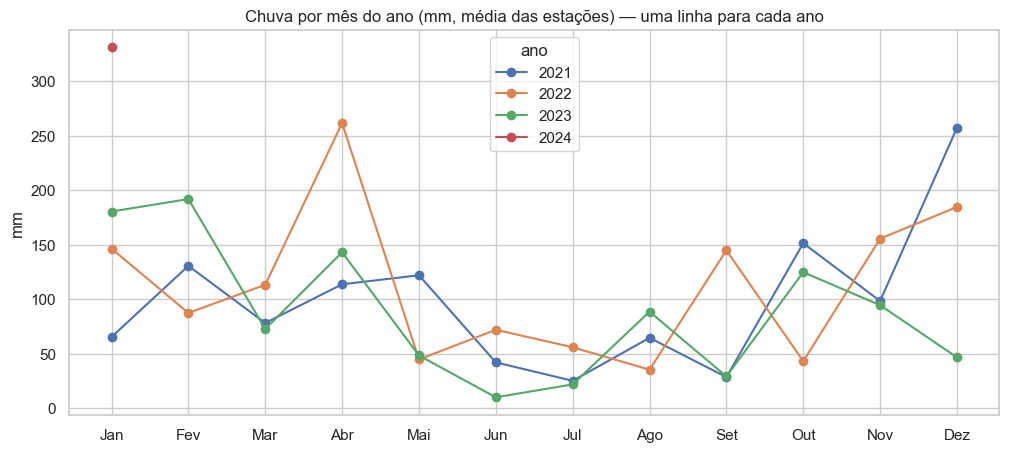

In [13]:
chuva_mes = chuva_cidade.groupby(chuva_cidade.index.to_period("M")).sum()
chuva_mes = chuva_mes[chuva_mes.index < chuva_mes.index.max()]   # tiro o último mês, que pode estar incompleto

tabela_chuva = chuva_mes.to_frame("chuva_mm")
tabela_chuva["ano"] = tabela_chuva.index.year
tabela_chuva["mes_do_ano"] = tabela_chuva.index.month
sazonal_chuva = tabela_chuva.pivot(index="mes_do_ano", columns="ano", values="chuva_mm")

sazonal_chuva.plot(figsize=(12, 5), marker="o")
plt.title("Chuva por mês do ano (mm, média das estações) — uma linha para cada ano")
plt.xticks(range(1, 13), ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"])
plt.xlabel("")
plt.ylabel("mm")
plt.show()

## 2.8 Quais estações registram mais chuva?
No primeiro notebook usei a média do acumulado de 24 horas. Como esse acumulado se sobrepõe (veja o início da seção), troquei por uma conta mais simples de interpretar: a média de chuva por dia de cada estação, multiplicada por 365, que dá uma **estimativa de chuva por ano**. Só entram estações com pelo menos 365 dias bons.

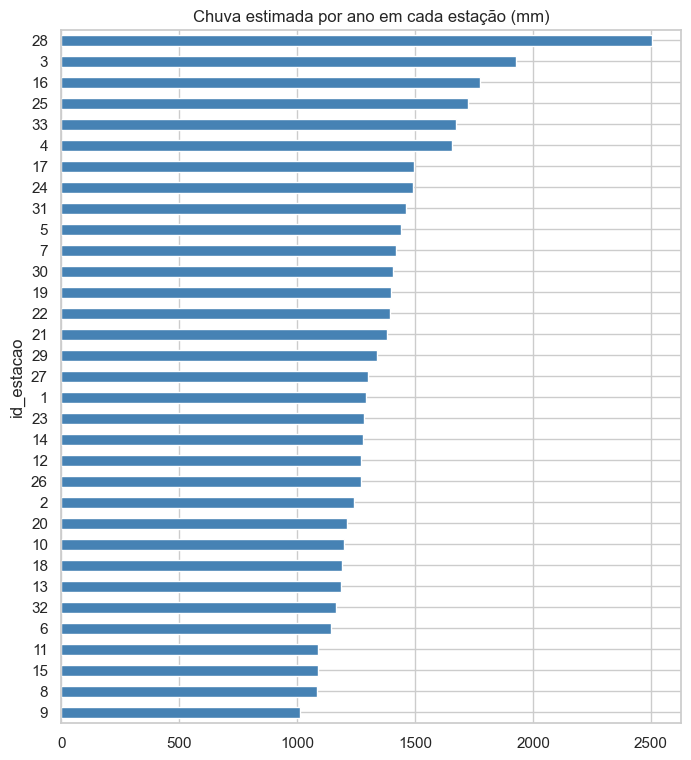

In [14]:
resumo_estacoes = dias_bons.groupby("id_estacao").agg(
    dias_bons=("chuva_mm", "count"),
    chuva_media_dia=("chuva_mm", "mean"),
)
resumo_estacoes = resumo_estacoes[resumo_estacoes["dias_bons"] >= 365]
resumo_estacoes["chuva_estimada_ano_mm"] = resumo_estacoes["chuva_media_dia"] * 365

resumo_estacoes["chuva_estimada_ano_mm"].sort_values().plot(kind="barh", figsize=(8, 9), color="steelblue")
plt.title("Chuva estimada por ano em cada estação (mm)")
plt.show()

## 2.9 O que aprendi sobre a chuva
- Para chuva por dia, **somo as medições de 15 minutos**; não uso média dos acumulados de 24 horas.
- Algumas estações têm dias com medições faltando; usei só os "dias bons".
- A tabela possui um possível erro relacionado a data

## 2.10 Salvando os dados para os próximos notebooks
Salvo a tabela de chuva por estação e dia (com a coluna `dia_bom`) e a chuva por mês da cidade.

Salvo em **parquet** em vez de CSV porque esse formato guarda o tipo de cada coluna (datas continuam sendo datas) e ocupa menos espaço. A pasta `data/processed/` fica fora do Git: os arquivos são recriados sempre que o notebook roda.

In [15]:
from pathlib import Path

PASTA_PROCESSED = Path("../data/processed")
PASTA_PROCESSED.mkdir(parents=True, exist_ok=True)

chuva_dia.to_parquet(PASTA_PROCESSED / "chuva_estacao_dia_2021.parquet", index=False)

# O índice de chuva_mes é do tipo Period; guardo cada mês como uma data (o dia 1 do mês)
chuva_mes.to_timestamp().to_frame("chuva_mm").to_parquet(PASTA_PROCESSED / "chuva_por_mes.parquet")

print("Arquivos salvos em:", PASTA_PROCESSED.resolve())

Arquivos salvos em: C:\Users\VitorCoutoFilho\OneDrive - Urca Energia Participações Ltda\Documentos\Vitor Couto Filho\data\processed
